In [13]:
import requests
from bs4 import BeautifulSoup

base_url = "https://en.wikipedia.org"
category_url = "https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_architect"

headers ={"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36",
    "Referer": "https://commons.wikimedia.org"
    }

response = requests.get(category_url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

container = soup.find("div", class_="mw-category mw-category-columns")

links = []

if container:
    for a in container.find_all("a", href=True):
      full_link = base_url + a["href"]
      links.append(full_link)

print(str(len(links)) + " adet alt kategori mevcut")
print()

for link in links:
    print(link)

56 adet alt kategori mevcut

https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_American_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Australian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Austrian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Azerbaijani_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Bangladeshi_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Belgian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Brazilian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_British_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Canadian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Chinese_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Croatian_architects
https://

In [14]:
subcategory_url = "https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Italian_architects"

response = requests.get(category_url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

container = soup.find("div", class_="mw-category mw-category-columns")

links = []

if container:
    for a in container.find_all("a", href=True):
        full_link = base_url + a["href"]
        links.append(full_link)

print(str(len(links)) + " adet alt kategori mevcut")
print()

for link in links:
    print(link)

56 adet alt kategori mevcut

https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_American_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Australian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Austrian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Azerbaijani_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Bangladeshi_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Belgian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Brazilian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_British_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Canadian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Chinese_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Croatian_architects
https://

In [15]:
# Step 0
# Define Architects
architect_urls = [
    "https://en.wikipedia.org/wiki/Category:Renzo_Piano_buildings",
    "https://en.wikipedia.org/wiki/Category:Carlo_Maderno_buildings",
    "https://en.wikipedia.org/wiki/Category:Luigi_Vanvitelli_buildings",
    "https://en.wikipedia.org/wiki/Category:Francesco_Borromini_buildings",
    "https://en.wikipedia.org/wiki/Category:Carlo_Rossi_buildings_and_structures",
    "https://en.wikipedia.org/wiki/Category:Bernardo_Antonio_Vittone_buildings",
    "https://en.wikipedia.org/wiki/Category:Pier_Luigi_Nervi_buildings",
    "https://en.wikipedia.org/wiki/Category:Andrea_Palladio_buildings"
]

In [16]:
import time
import pandas as pd
from types import NoneType
import numpy as np
from PIL import Image
from io import BytesIO

results = []
all_building_links = []
architect_names_list = []

# Step 1
# Collect all building links
for architect_category_url in architect_urls:

    # Extract architect name from the category URL
    architect_name = architect_category_url.split("Category:")[-1].replace("_buildings", "").replace("_", " ")

    print(f"Collecting building from architect: {architect_name}")

    response = requests.get(architect_category_url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    container = soup.find("div", class_="mw-category mw-category-columns")

    current_architect_links = []

    for a in container.find_all("a", href=True):
        full_link = base_url + a["href"]
        current_architect_links.append((full_link, architect_name))

    print(f"  {len(current_architect_links)} links found from {architect_category_url}")
    all_building_links.extend(current_architect_links)
    architect_names_list.append(architect_name)
    time.sleep(2)

print(f"\nTotal unique building links collected: {len(all_building_links)}")

architect_names = ""
architect_names = ", ".join(architect_names_list)

  56 links found from https://en.wikipedia.org/wiki/Category:Renzo_Piano_buildings
  14 links found from https://en.wikipedia.org/wiki/Category:Carlo_Maderno_buildings
  15 links found from https://en.wikipedia.org/wiki/Category:Luigi_Vanvitelli_buildings
  15 links found from https://en.wikipedia.org/wiki/Category:Francesco_Borromini_buildings
  20 links found from https://en.wikipedia.org/wiki/Category:Carlo_Rossi_buildings_and_structures
  20 links found from https://en.wikipedia.org/wiki/Category:Bernardo_Antonio_Vittone_buildings
  23 links found from https://en.wikipedia.org/wiki/Category:Pier_Luigi_Nervi_buildings
  49 links found from https://en.wikipedia.org/wiki/Category:Andrea_Palladio_buildings

Total unique building links collected: 212


In [20]:
# Step 2
# Scrape info for each link
results = []
processed_buildings_no = len(all_building_links)

for url, architect in all_building_links[:processed_buildings_no]:
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    # Title
    title_tag = soup.find("h1")
    title_text = title_tag.get_text(strip=True) if title_tag else None

    # Skip list/category pages
    if title_text and (title_text.lower().startswith("list of") or title_text.lower().startswith("category:")):
        continue

    # Content
    content = soup.find("div", id="mw-content-text")

    max_paragraphs = 3
    paragraphs = []
    first_image_url = None
    img_npy = None
    country = None
    building_type = None
    img_tag = None

    if content:
        for p in content.find_all("p"):
            text = p.get_text(strip=True)
            if text:
                paragraphs.append(text)
            if len(paragraphs) >= max_paragraphs:
                break

        # Find first non-SVG image
        for candidate in content.find_all("img"):
            src = candidate.get("src", "")
            # Ensure it's not a SVG
            if src and not src.lower().endswith(".svg"):
                img_tag = candidate
                break

        if img_tag and img_tag.get("src"):
            first_image_url = "https:" + img_tag["src"]
            try:
                img_response = requests.get(first_image_url, headers=headers)
                img = Image.open(BytesIO(img_response.content))
                if img.mode in ("P", "PA"):
                    img = img.convert("RGBA").convert("RGB")
                else:
                    img = img.convert("RGB")
                img_npy = np.array(img)
            except Exception as e:
                first_image_url = None
                img_npy = None

    # Coordinates
    coord_tag = soup.find("span", class_="geo-dec")
    coordinates = coord_tag.get_text(strip=True) if coord_tag else None

    # Infobox for country and building type
    infobox = soup.find("table", class_="infobox")
    if infobox:
        for row in infobox.find_all("tr"):
            th = row.find("th")
            td = row.find("td")
            if th and td:
                label = th.get_text(strip=True).lower()
                value = td.get_text(" ", strip=True)

                # Extract building type
                if "type" in label:
                    building_type = value

                # Extract country
                if country is None:
                    if "country" in label:
                        country = value
                    elif "location" in label: # location as fallback for country
                        parts = [p.strip() for p in value.split(",")]
                        if parts:
                            country = parts[-1]

    results.append({
        "url"            : url,
        "title"          : title_text,
        "country"        : country,
        "building_type"  : building_type,
        "coordinates"    : coordinates,
        "paragraphs"     : paragraphs,
        "first_image_url": first_image_url,
        "img_npy"        : img_npy,
        "architect"      : architect # Add the architect name here
    })

    time.sleep(2)
    print("Toplam Çekilen Kayıt:", len(results))

print(f"\nFinished scraping. {len(results)}/{processed_buildings_no} buildings were scraped.")

Toplam Çekilen Kayıt: 1
Toplam Çekilen Kayıt: 2
Toplam Çekilen Kayıt: 3
Toplam Çekilen Kayıt: 4
Toplam Çekilen Kayıt: 5
Toplam Çekilen Kayıt: 6
Toplam Çekilen Kayıt: 7
Toplam Çekilen Kayıt: 8
Toplam Çekilen Kayıt: 9
Toplam Çekilen Kayıt: 10
Toplam Çekilen Kayıt: 11
Toplam Çekilen Kayıt: 12
Toplam Çekilen Kayıt: 13
Toplam Çekilen Kayıt: 14
Toplam Çekilen Kayıt: 15
Toplam Çekilen Kayıt: 16
Toplam Çekilen Kayıt: 17
Toplam Çekilen Kayıt: 18
Toplam Çekilen Kayıt: 19
Toplam Çekilen Kayıt: 20
Toplam Çekilen Kayıt: 21
Toplam Çekilen Kayıt: 22
Toplam Çekilen Kayıt: 23
Toplam Çekilen Kayıt: 24
Toplam Çekilen Kayıt: 25
Toplam Çekilen Kayıt: 26
Toplam Çekilen Kayıt: 27
Toplam Çekilen Kayıt: 28
Toplam Çekilen Kayıt: 29
Toplam Çekilen Kayıt: 30
Toplam Çekilen Kayıt: 31
Toplam Çekilen Kayıt: 32
Toplam Çekilen Kayıt: 33
Toplam Çekilen Kayıt: 34
Toplam Çekilen Kayıt: 35
Toplam Çekilen Kayıt: 36
Toplam Çekilen Kayıt: 37
Toplam Çekilen Kayıt: 38
Toplam Çekilen Kayıt: 39
Toplam Çekilen Kayıt: 40
Toplam Çe

In [21]:
# Step 3
# Create a DataFrame
df = pd.DataFrame(results)
df.head(len(df))

,url,title,country,building_type,coordinates,paragraphs,first_image_url,img_npy,architect
0,https://en.wikipedia.org/wiki/565_Broome_Street,565 Broome Street,U.S.,Residential Condominiums,40.72417°N 74.00556°W,[565 Broome Streetis a luxury residential buil...,https://upload.wikimedia.org/wikipedia/commons...,"[[[2, 0, 14], [1, 0, 13], [1, 0, 13], [0, 0, 1...",Renzo Piano
1,https://en.wikipedia.org/wiki/Academy_Museum_o...,Academy Museum of Motion Pictures,U.S.,Motion picture history,34.06333°N 118.36083°W,[TheAcademy Museum of Motion Picturesis a film...,https://upload.wikimedia.org/wikipedia/en/thum...,"[[[186, 158, 94], [186, 158, 94], [186, 158, 9...",Renzo Piano
2,https://en.wikipedia.org/wiki/Accademia_Nazion...,Accademia Nazionale di Santa Cecilia Musical I...,Rome,None,41.928931°N 12.474794°E,[TheAccademia Nazionale di Santa Cecilia Music...,https://upload.wikimedia.org/wikipedia/commons...,"[[[179, 138, 94], [179, 138, 94], [179, 138, 9...",Renzo Piano
3,https://en.wikipedia.org/wiki/Aquarium_of_Genoa,Aquarium of Genoa,Italy,None,44.4102889°N 8.9265472°E,[TheAquarium of Genoa(Acquario di Genova) is t...,https://upload.wikimedia.org/wikipedia/en/thum...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",Renzo Piano
4,https://en.wikipedia.org/wiki/Art_Institute_of...,Art Institute of Chicago Building,United States,None,41.8796°N 87.6237°W,[TheArt Institute of Chicago Building(initial ...,None,None,Renzo Piano
...,...,...,...,...,...,...,...,...,...
206,https://en.wikipedia.org/wiki/Villa_Trissino_(...,Villa Trissino (Meledo di Sarego),Italy,None,45.42833°N 11.41361°E,[Villa Trissinois an incompletepatrician villa...,None,None,Andrea Palladio
207,https://en.wikipedia.org/wiki/Villa_Valmarana_...,Villa Valmarana (Lisiera),Italy,None,45.5798278°N 11.6102583°E,[TheVilla Valmarana(also known asValmarana Sca...,None,None,Andrea Palladio
208,https://en.wikipedia.org/wiki/Villa_Valmarana_...,Villa Valmarana (Vigardolo),None,None,45.6073611°N 11.58444°E,[45°36′26.50″N11°35′4″E﻿ / ﻿45.6073611°N 11.58...,None,None,Andrea Palladio
209,https://en.wikipedia.org/wiki/Villa_Zeno,Villa Zeno,Italy,None,45.70028°N 12.64306°E,"[Villa Zenois a patricianvillaatCessalto,Venet...",None,None,Andrea Palladio


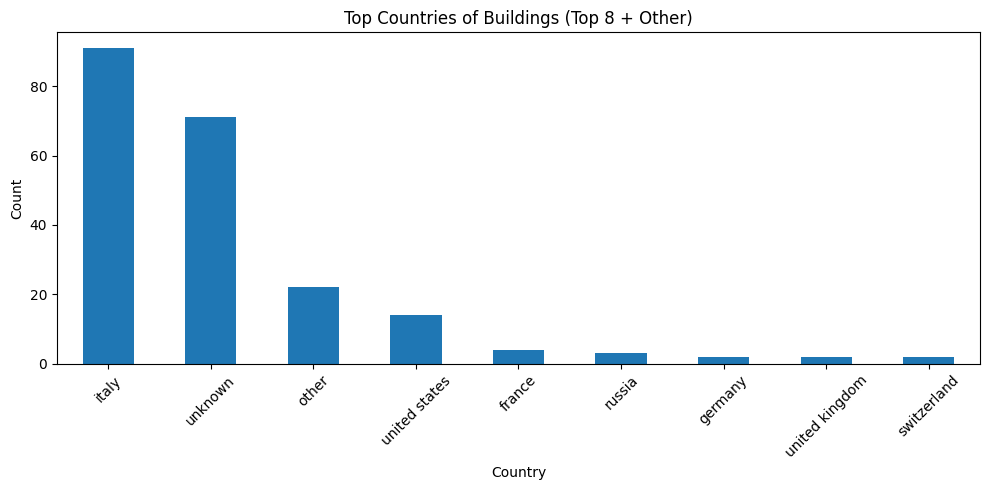

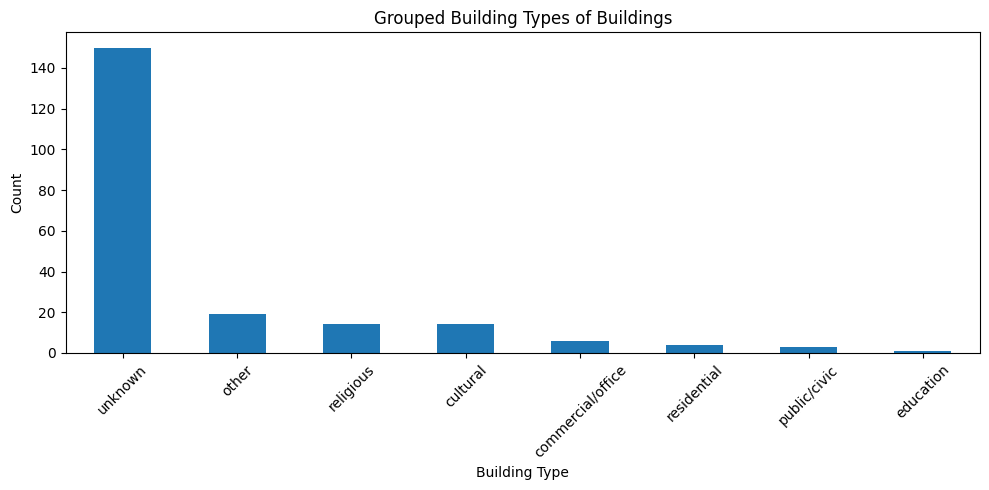

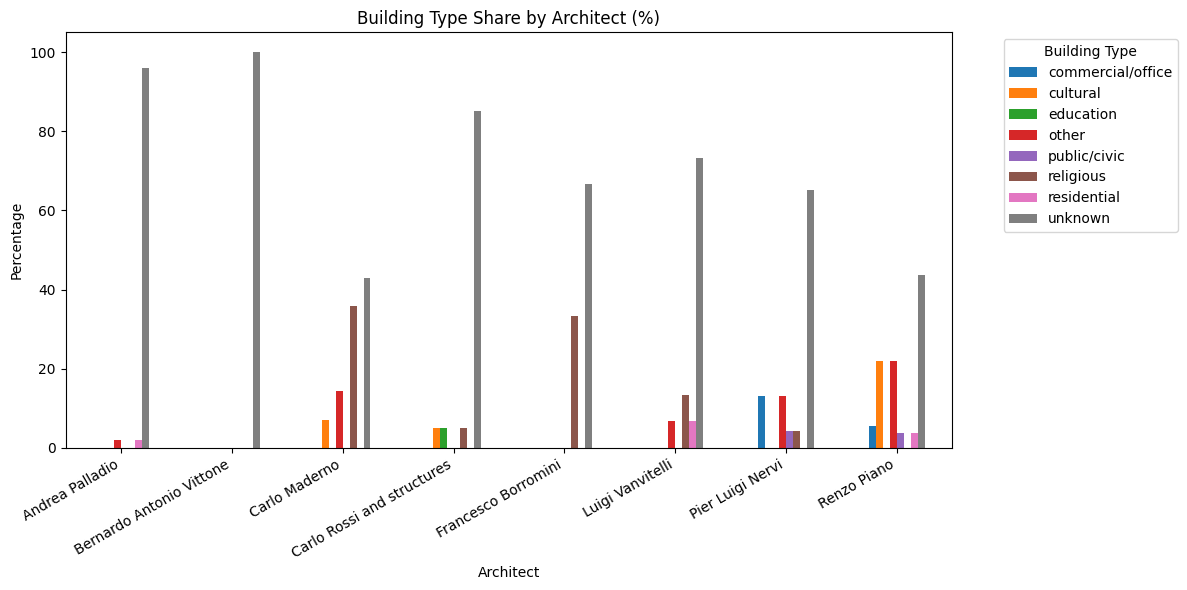

Top normalized countries:
country_normalized
italy             91
unknown           71
united states     14
france             4
russia             3
switzerland        2
germany            2
united kingdom     2
malta              2
taiwan             2
australia          2
new caledonia      1
japan              1
flaminio           1
netherlands        1
it                 1
portugal.          1
28                 1
poland             1
tallinn            1
Name: count, dtype: int64

Top grouped building types:
building_type_group
unknown              150
other                 19
religious             14
cultural              14
commercial/office      6
residential            4
public/civic           3
education              1
Name: count, dtype: int64


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Eğer df oluşmadıysa:
# df = pd.DataFrame(results)

def clean_text(x):
    if pd.isna(x):
        return None
    x = str(x).strip().lower()
    x = re.sub(r"\s+", " ", x)
    return x

# ---------------------------
# 1) COUNTRY CLEANING
# ---------------------------
df["country_clean"] = df["country"].apply(clean_text)

def normalize_country(x):
    if x is None or x == "":
        return "unknown"

    x = x.lower().strip()

    # United States
    if any(k in x for k in [
        "united states", "u.s.", "u.s", "usa", "u.s.a",
        "new york", "california", "los angeles", "texas",
        "illinois", "chicago", "georgia", "miami", "boston",
        "philadelphia", "washington", "seattle"
    ]):
        return "united states"

    # Italy
    if any(k in x for k in [
        "italy", "italia", "rome", "roma", "milan", "milano",
        "turin", "torino", "genoa", "genova", "venice", "venezia",
        "florence", "firenze", "naples", "napoli", "bologna",
        "palermo", "vatican city", "pisa", "parma", "sicily"
    ]):
        return "italy"

    # United Kingdom
    if any(k in x for k in [
        "united kingdom", "uk", "britain", "england",
        "scotland", "wales", "london", "manchester", "glasgow"
    ]):
        return "united kingdom"

    # France
    if any(k in x for k in [
        "france", "paris", "lyon", "marseille", "french"
    ]):
        return "france"

    # Germany
    if any(k in x for k in [
        "germany", "berlin", "munich", "hamburg", "frankfurt", "german"
    ]):
        return "germany"

    # Switzerland
    if any(k in x for k in [
        "switzerland", "zurich", "geneva", "basel", "swiss"
    ]):
        return "switzerland"

    # Spain
    if any(k in x for k in [
        "spain", "madrid", "barcelona", "seville", "valencia", "spanish"
    ]):
        return "spain"

    # Japan
    if any(k in x for k in [
        "japan", "tokyo", "osaka", "kyoto", "yokohama"
    ]):
        return "japan"

    # Australia
    if any(k in x for k in [
        "australia", "sydney", "melbourne", "brisbane"
    ]):
        return "australia"

    # Russia
    if any(k in x for k in [
        "russia", "moscow", "saint petersburg", "st. petersburg", "russian"
    ]):
        return "russia"

    # Austria
    if any(k in x for k in [
        "austria", "vienna", "austrian"
    ]):
        return "austria"

    # Poland
    if any(k in x for k in [
        "poland", "warsaw", "krakow", "polish"
    ]):
        return "poland"

    # Netherlands
    if any(k in x for k in [
        "netherlands", "amsterdam", "rotterdam", "dutch", "holland"
    ]):
        return "netherlands"

    # Belgium
    if any(k in x for k in [
        "belgium", "brussels", "antwerp", "belgian"
    ]):
        return "belgium"

    # Turkey
    if any(k in x for k in [
        "turkey", "istanbul", "ankara", "izmir", "turkish"
    ]):
        return "turkey"

    return x

df["country_normalized"] = df["country_clean"].apply(normalize_country)

top_n_countries = 8
top_countries = df["country_normalized"].value_counts().head(top_n_countries).index
df["country_top"] = df["country_normalized"].apply(lambda x: x if x in top_countries else "other")

# ---------------------------
# 2) BUILDING TYPE CLEANING
# ---------------------------
df["building_type_clean"] = df["building_type"].apply(clean_text)

def map_building_type(x):
    if x is None or x == "":
        return "unknown"

    # Religious
    if any(k in x for k in [
        "church", "cathedral", "chapel", "basilica", "mosque",
        "temple", "religious", "monastery", "convent", "abbey", "synagogue"
    ]):
        return "religious"

    # Residential
    if any(k in x for k in [
        "house", "residential", "apartment", "villa", "housing",
        "dwelling", "palace", "home", "residence", "castle"
    ]):
        return "residential"

    # Cultural
    if any(k in x for k in [
        "museum", "gallery", "theatre", "theater", "opera",
        "cultural", "cinema", "auditorium", "arts center", "exhibition"
    ]):
        return "cultural"

    # Commercial / Office
    if any(k in x for k in [
        "office", "headquarters", "tower", "commercial",
        "business", "bank", "skyscraper"
    ]):
        return "commercial/office"

    # Education
    if any(k in x for k in [
        "school", "university", "campus", "library",
        "education", "college", "institute", "academy"
    ]):
        return "education"

    # Infrastructure / Transport
    if any(k in x for k in [
        "bridge", "station", "airport", "terminal",
        "railway", "metro", "infrastructure", "transport", "harbor", "port"
    ]):
        return "infrastructure"

    # Public / Civic
    if any(k in x for k in [
        "city hall", "town hall", "public", "civic", "municipal",
        "courthouse", "government", "parliament", "administrative", "plaza"
    ]):
        return "public/civic"

    # Sports / Leisure
    if any(k in x for k in [
        "stadium", "arena", "sports", "gymnasium", "leisure", "park"
    ]):
        return "sports/leisure"

    # Healthcare
    if any(k in x for k in [
        "hospital", "clinic", "medical", "health"
    ]):
        return "healthcare"

    # Memorial / Monument
    if any(k in x for k in [
        "memorial", "monument", "mausoleum", "tomb"
    ]):
        return "memorial/monument"

    return "other"

df["building_type_group"] = df["building_type_clean"].apply(map_building_type)

# ---------------------------
# 3) GRAPH 1 - COUNTRY
# ---------------------------
plt.figure(figsize=(10,5))
df["country_top"].value_counts().plot(kind="bar")
plt.title("Top Countries of Buildings (Top 8 + Other)")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------
# 4) GRAPH 2 - BUILDING TYPE
# ---------------------------
plt.figure(figsize=(10,5))
df["building_type_group"].value_counts().plot(kind="bar")
plt.title("Grouped Building Types of Buildings")
plt.xlabel("Building Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------
# 5) GRAPH 3 - BY ARCHITECT
# ---------------------------
pivot = pd.crosstab(df["architect"], df["building_type_group"], normalize="index") * 100

pivot.plot(kind="bar", figsize=(12,6))
plt.title("Building Type Share by Architect (%)")
plt.xlabel("Architect")
plt.ylabel("Percentage")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Building Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ---------------------------
# 6) CHECK RESULTS
# ---------------------------
print("Top normalized countries:")
print(df["country_normalized"].value_counts(dropna=False).head(20))

print("\nTop grouped building types:")
print(df["building_type_group"].value_counts(dropna=False).head(20))



In [24]:
import json
from datetime import datetime

metadata = {
    "project"          : "MBL549E Case Study 2",
    "data_source"      : [f"{architect_urls}"],
    "category_label"   : f"[{architect_names}]",
    "research_question": f"Research Question: How are Italian architects' buildings ({architect_names}) distributed\ngeographically and by building type?",
    "total_records"    : len(df),
    "scraping_date"    : datetime.today().strftime("%Y-%m-%d"),
    "rate_limit"       : "time.sleep(2) between every request + custom User-Agent header",
    "group_members"    : ["Merve Civcik - 523251015", "Hamdi Çakır - 523241022", "Şeyma Olcay - 523241023"]
}

with open("metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("metadata.json saved.")

dataDictionary = {
  "url": {
    "type": "string",
    "description": "Full Wikipedia URL of the building article."
  },
  "title": {
    "type": "string",
    "description": "Name of the building from the Wikipedia article title."
  },
  "country": {
    "type": "string",
    "description": "Country where the building is located, extracted from the infobox."
  },
  "building_type": {
    "type": "string",
    "description": "Functional type or use of the building (e.g. museum, office, residential)."
  },
  "paragraphs": {
    "type": "list of strings",
    "description": "First two paragraphs from the Wikipedia article body."
  },
  "first_image_url": {
    "type": "string",
    "description": "URL of the first image found in the Wikipedia article."
  },
  "img_npy": {
    "type": "numpy array (H x W x 3)",
    "description": "First image stored as an RGB numpy array."
  }
}

with open("dataDictionary.json", "w", encoding="utf-8") as f:
    json.dump(dataDictionary, f, indent=2, ensure_ascii=False)

print(f"\ndataDictionary.json saved.")

# Save as Pickle
df.to_pickle("dataset.pkl")
print(f"\ndataset.pkl saved.")

metadata.json saved.

dataDictionary.json saved.

dataset.pkl saved.


In [26]:
# Download all files to local machine
from google.colab import files

files.download("dataset.pkl")
files.download("dataDictionary.json")
files.download("metadata.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>